In [69]:
import numpy as np
import matplotlib.pyplot as plt
import limpy.lline as ll
#from plotsettings import *
import limpy.theory as lt
import utils 
from plotsettings import *

In [70]:
boxsize=80
halo_redshift=5.8
nu_obs=280
dnu=2.8
line_name='CII'
ndim_original=3

mmin=1e10
ngrid=512


halo_file='/Users/anirbanroy/Documents/21cmFAST/Output_files/Halo_lists/halos_z5.80_512_80Mpc'

proj_L=utils.length_projection(nu_obs=nu_obs, dnu=dnu, line_name=line_name)

hm, cm=utils.make_halocat(halo_file, filetype='dat',boxsize=boxsize)

mass_cut=hm >= mmin
halomass_cut=hm[mass_cut]

print("Calculating line luminosities")
lum_line=np.zeros(len(halomass_cut))
for i in range(len(halomass_cut)):
    lum_line[i]=ll.mhalo_to_lline(halomass_cut[i],halo_redshift,line_name=line_name)

print("making the luminsoity grid")
gi=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift, line_name='CII',\
                        halo_cutoff_mass=1e11, use_scatter=False,halocat_file_type='dat', unit='mpc')

print("shape of gi is", np.shape(gi))

Calculating line luminosities
making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
shape of gi is (134217728,)


In [71]:
g3d=gi.reshape(512,512,512)
print("Calculating power spectra")
g2d=utils.slice_2d(g3d,512,1)
k_ns, pk_ns= utils.powerspectra_2d(g2d, boxsize, ngrid, volume_normalization=False)

Calculating power spectra
The dimension of data 3
V_cell 0.0244140625


In [72]:
import powerbox as pbox
p_2i, k_2i = pbox.get_power(g2d,80, bin_ave=False, vol_normalised_power=False)

p_3i, k_3i = pbox.get_power(g3d,80, bin_ave=False, vol_normalised_power=False)


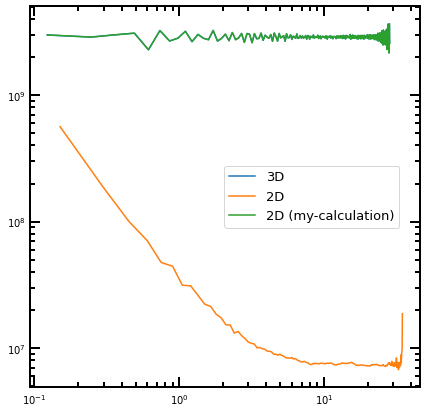

In [73]:
plt.loglog(k2_i[1:], p_2i, label="3D")
plt.loglog(k_3i[1:], p_3i, label="2D")
plt.loglog(k_ns, pk_ns, label="2D (my-calculation)")

#plt.xlim((2*np.pi/80), (np.pi*512/80))
plt.legend(loc=0)

In [74]:
dk_sims=((k_ns)**3*(pk_ns))/(2*np.pi**2)

In [75]:
print("making the luminsoity grid")
gi=ll.calc_intensity_3d(boxsize, ngrid, halo_file,halo_redshift, line_name='CII',\
                        halo_cutoff_mass=1e11, use_scatter=True,halocat_file_type='dat', unit='mpc')

k_s, pk_s= utils.powerspectra_2d(gi, boxsize, ngrid, project_length=0.10, volume_normalization=False)

dk_s_sims=((k_s)**3*(pk_s))/(2*np.pi**2)

making the luminsoity grid
Minimum halo mass: 336666900.0
Maximum halo mass: 1788722000000.0
The number of cells to be projected= 1
The dimension of data 1
V_cell 0.0244140625


In [76]:
k=k_s
pk_theory=lt.Pk_line(k,5.8,line_name=line_name,label='total',pk_unit='intensity')
dk_theory=k**3*pk_theory/(2*np.pi**2)

In [77]:
kkul, dkkul=np.loadtxt("/Users/anirbanroy/Downloads/CII_kulkarni_z6.3.dat", unpack=True)

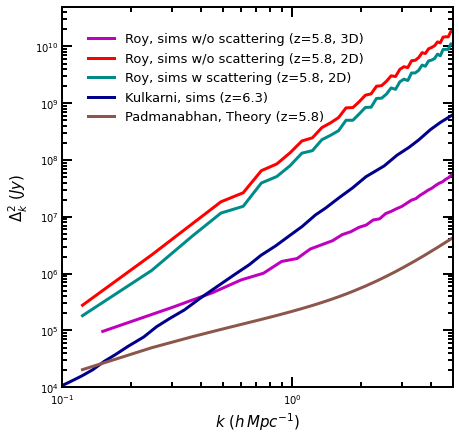

In [81]:
d_3i=(k_3i[1:])**3 * p_3i/2.0/np.pi**2
plt.plot(k_3i[1:], d_3i, lw=3, color='m', label="Roy, sims w/o scattering (z=5.8, 3D)")

plt.plot(k, dk_sims,lw=3,color='r', label="Roy, sims w/o scattering (z=5.8, 2D)")
plt.plot(k, dk_s_sims,lw=3,color='darkcyan', label="Roy, sims w scattering (z=5.8, 2D)")

plt.plot(kkul, dkkul,lw=3, color='darkblue',label="Kulkarni, sims (z=6.3)")
plt.plot(k, dk_theory,lw=3,color='C5', label="Padmanabhan, Theory (z=5.8)")


plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-1, 5)
plt.ylim(1e4, 5e10)
plt.legend(loc=0, frameon=False, fontsize=13)

#plt.xlim((2*np.pi)/80, (np.pi*512)/80)

plt.ylabel(r"$\Delta_k^2\,\,(Jy)$")
plt.xlabel(r"$k\,\,(h\,Mpc^{-1})$")

plt.savefig("powerspecta.pdf")

In [ ]:
(2*np.pi/80)

In [53]:
densf='/Users/anirbanroy/Documents/21cmFAST/Boxes/updated_smoothed_deltax_z005.80_512_80Mpc'
with open(densf, 'rb') as f:
    dens_gas = np.fromfile(f, dtype='f', count=-1)
    
dg=dens_gas.reshape(512,512,512)

In [16]:
kd, pkd=utils.powerspectra_2d(dg, boxlength, ngrid, project_length=0.1)

The number of cells to be projected= 1
The dimension of data 3
V_cell 0.0244140625


In [24]:
pk3d, k3d = pbox.get_power(dg,80, bin_ave=False,   vol_normalised_power=False)

In [25]:
ni=utils.slice_2d(dg,512,1)

The dimension of data 3


In [26]:
pk2d, k2d = pbox.get_power(ni,80, bin_ave=False,   vol_normalised_power=False)

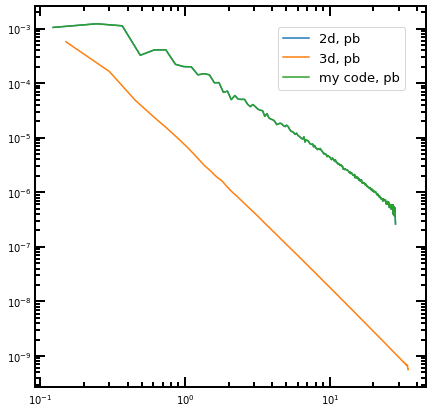

In [27]:
plt.plot(k2d[1:], pk2d, label="2d, pb")
plt.plot(k3d[1:], pk3d, label="3d, pb")
plt.plot(kd, pkd, label="my code, pb")

plt.yscale("log")
plt.xscale("log")
plt.legend(loc=0)